<a href="https://colab.research.google.com/github/KedaarK/ML-Experiments-D17A/blob/main/Batch_A/MLExp8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 🌐 **Introduction to OpenML**

**OpenML** (Open Machine Learning) is a free and collaborative platform designed for sharing machine learning datasets, models, and experiments.  
It provides an extensive collection of benchmark datasets that can be easily accessed via Python using the `openml` library.

**Why OpenML?**
- 📚 Provides **thousands of datasets** for machine learning and data science.  
- ⚙️ Offers **easy integration** with popular libraries such as `scikit-learn` and `pandas`.  
- 💡 Supports **reproducible research** by allowing users to share and track their experiments.  
- 🔗 Each dataset has a **unique ID**, making it simple to load specific datasets directly into code.


In [ ]:
!pip install openml -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 35.2 MB/s eta 0:00:00


### 🧩 **Importing and Installing Libraries**

In this step, we first install the `openml` library, which allows us to fetch datasets directly from the OpenML platform.  
We then import the essential Python libraries:

- **openml** → to access and load datasets from the OpenML repository.  
- **pandas** → for data manipulation and analysis.  
- **matplotlib.pyplot** and **seaborn** → for data visualization and graphical representation.  
- **train_test_split** → to divide the dataset into training and testing subsets.  
- **RandomForestClassifier** → to train our predictive model.  
- **classification_report**, **confusion_matrix**, **accuracy_score** → for model performance evaluation.

These imports set up our environment for end-to-end machine learning workflow — from loading data to evaluating results.

In [ ]:
import openml
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
dataset = openml.datasets.get_dataset(35)
X, y, _, _ = dataset.get_data(target=dataset.default_target_attribute)
print(dataset)

OpenML Dataset
Name.........: dermatology
Version......: 1
Format.......: ARFF
Upload Date..: 2014-04-06 23:22:05
Licence......: Public
Download URL.: https://api.openml.org/data/v1/download/35/dermatology.arff
OpenML URL...: https://www.openml.org/d/35
# of features: None


### 📥 **Loading the Dermatology  Dataset**

We load the **dermatology dataset** (OpenML ID: 35) using the `openml.datasets.get_dataset()` function.  
This database contains 34 attributes, 33 of which are linear valued and one of them is nominal.


In the dataset constructed for this domain, the family history feature has the value 1 if any of these diseases has been observed in the family, and 0 otherwise. The age feature simply represents the age of the patient. Every other feature (clinical and histopathological) was given a degree in the range of 0 to 3. Here, 0 indicates that the feature was not present, 3 indicates the largest amount possible, and 1, 2 indicate the relative intermediate values.

Attribute Information: -- Complete attribute documentation: Clinical Attributes: (take values 0, 1, 2, 3, unless otherwise indicated) 1: erythema 2: scaling 3: definite borders 4: itching 5: koebner phenomenon 6: polygonal papules 7: follicular papules 8: oral mucosal involvement 9: knee and elbow involvement 10: scalp involvement 11: family history, (0 or 1) 34: Age (linear)

In [ ]:
print("✅ dermatology dataset loaded successfully!")
print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")


✅ dermatology dataset loaded successfully!
Features shape: (366, 34)
Target distribution:
class
1    112
3     72
2     61
5     52
4     49
6     20
Name: count, dtype: int64


### ✂️ **Splitting the Dataset into Training and Testing Sets**

To evaluate our model’s generalization ability, we split the data into two parts:

- **80% training data** → used to train the model.  
- **20% testing data** → used to test model performance on unseen data.

We use `train_test_split()` from scikit-learn with parameters:
- `test_size=0.2` → 20% for testing.  
- `random_state=42` → ensures reproducibility.  
- `stratify=y` → maintains the same class ratio in both training and test sets.

This step ensures that our model is trained on one portion of the dataset and evaluated on another, preventing overfitting.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### 🌲 **Training the Random Forest Model**

Here we initialize and train a **Random Forest Classifier** — an ensemble learning method that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

- `n_estimators=100` → builds 100 decision trees.  
- `random_state=42` → ensures consistent results each time the code runs.

We train the model using `model.fit(X_train, y_train)`, which allows it to learn patterns and relationships between the features and the target variable.


In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

### 🎯 **Making Predictions on the Test Set**

After training, the model is used to predict outcomes on the unseen **test data (`X_test`)** using the `.predict()` method.  
The predicted labels are stored in `y_pred`.

These predictions will later be compared to the actual labels (`y_test`) to measure how accurate and reliable our model is.

In [ ]:
y_pred = model.predict(X_test)


### 📊 **Generating and Interpreting the Classification Report**

The **classification report** provides a detailed summary of the model’s performance across each class.  
It includes key metrics such as:

- **Precision** → fraction of correctly predicted positive instances among all predicted positives.  
- **Recall (Sensitivity)** → fraction of correctly predicted positive instances among all actual positives.  
- **F1-Score** → harmonic mean of precision and recall, balancing both metrics.  
- **Support** → number of true instances for each class in the dataset.

We convert the report to a pandas DataFrame for better visualization and readability.  

In [ ]:
report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

print("\n📊 Classification Report:")
print(report_df)



📊 Classification Report:
              precision    recall  f1-score    support
1              1.000000  1.000000  1.000000  23.000000
2              0.909091  0.833333  0.869565  12.000000
3              1.000000  1.000000  1.000000  15.000000
4              0.818182  0.900000  0.857143  10.000000
5              1.000000  1.000000  1.000000  10.000000
6              1.000000  1.000000  1.000000   4.000000
accuracy       0.959459  0.959459  0.959459   0.959459
macro avg      0.954545  0.955556  0.954451  74.000000
weighted avg   0.960688  0.959459  0.959543  74.000000


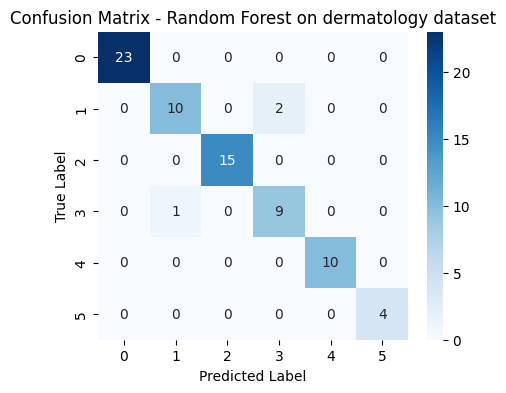

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest on dermatology dataset")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### 🎯 **Calculating the Model’s Accuracy**

Finally, we calculate the model’s overall **accuracy** using the `accuracy_score()` function.  
Accuracy measures the proportion of correctly predicted samples out of the total test samples.

This gives a quick and intuitive measure of how well the Random Forest model performs on the dermatology dataset.

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"\n🎯 Model Accuracy: {accuracy*100:.2f}%")


🎯 Model Accuracy: 95.95%
